In [1]:
import numpy as np 
import pandas as pd 

In [2]:
df = pd.read_csv('indian_engineering_student_placement.csv')
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [3]:
df.shape

(5000, 23)

In [4]:
df_target = pd.read_csv('placement_targets.csv')

In [5]:
df_target.head()

,Student_ID,placement_status,salary_lpa
0,1,Placed,14.95
1,2,Placed,14.91
2,3,Placed,17.73
3,4,Placed,14.52
4,5,Placed,15.91


In [6]:
df_target['placement_status'].value_counts()

placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64

In [7]:
df_target.value_counts()

Student_ID  placement_status  salary_lpa
5000        Placed            20.00         1
1           Placed            14.95         1
2           Placed            14.91         1
3           Placed            17.73         1
4           Placed            14.52         1
                                           ..
13          Placed            12.35         1
12          Placed            19.73         1
11          Placed            9.74          1
10          Placed            17.66         1
9           Placed            18.83         1
Name: count, Length: 5000, dtype: int64

In [9]:
df.isnull().sum()

Student_ID                        0
gender                            0
branch                            0
cgpa                              0
tenth_percentage                  0
twelfth_percentage                0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
internships_completed             0
coding_skill_rating               0
communication_skill_rating        0
aptitude_skill_rating             0
hackathons_participated           0
certifications_count              0
sleep_hours                       0
stress_level                      0
part_time_job                     0
family_income_level               0
city_tier                         0
internet_access                   0
extracurricular_involvement    1006
dtype: int64

In [10]:
df['extracurricular_involvement'].value_counts()

extracurricular_involvement
Medium    1501
Low       1485
High      1008
Name: count, dtype: int64

In [17]:
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,1,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,0,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,0,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,1,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,1,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [18]:
df['branch'].value_counts()

branch
CSE    1522
ECE    1336
IT      963
ME      725
CE      454
Name: count, dtype: int64

In [21]:
data = pd.merge(df, df_target, on='Student_ID')

In [22]:
data.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,1,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,0,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,0,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,1,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,1,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [23]:
pd.get_dummies(data, columns=['branch'])

,Student_ID,gender,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa,branch_CE,branch_CSE,branch_ECE,branch_IT,branch_ME
0,1,1,8.74,74.0,75.0,0,3.8,71.1,7,3,...,Tier 2,Yes,Medium,Placed,14.95,False,False,True,False,False
1,2,0,7.80,75.3,69.7,0,6.3,69.5,5,1,...,Tier 3,Yes,Low,Placed,14.91,False,False,True,False,False
2,3,0,6.95,62.8,68.3,0,1.5,62.5,8,2,...,Tier 2,Yes,High,Placed,17.73,False,False,False,True,False
3,4,1,7.46,57.9,51.4,1,4.7,64.6,6,2,...,Tier 1,Yes,Low,Placed,14.52,False,False,True,False,False
4,5,1,6.86,61.3,73.5,2,5.2,75.9,3,3,...,Tier 1,Yes,Medium,Placed,15.91,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,0,10.00,90.4,98.3,0,3.7,75.3,6,3,...,Tier 3,Yes,Low,Placed,19.35,False,False,False,True,False
4996,4997,1,7.76,74.3,72.6,2,6.3,72.3,4,4,...,Tier 1,Yes,Low,Not Placed,0.00,False,False,False,True,False
4997,4998,1,7.79,64.0,71.2,2,2.0,63.8,6,1,...,Tier 2,No,Medium,Placed,19.13,False,False,False,True,False
4998,4999,0,8.76,74.3,74.0,0,5.1,72.0,6,4,...,Tier 2,Yes,High,Placed,16.53,False,False,True,False,False


In [24]:
data.describe()

,Student_ID,gender,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,0.599800,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1443.520003,0.489988,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,1.000000,0.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,1250.750000,0.000000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,2500.500000,1.000000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,3750.250000,1.000000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,5000.000000,1.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


In [26]:
import matplotlib.pyplot as plt 

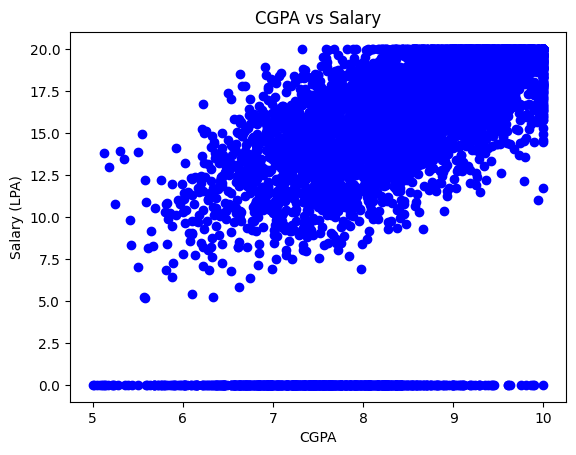

In [29]:
plt.scatter(data['cgpa'], data['salary_lpa'], color='blue', marker='o')
plt.xlabel("CGPA")
plt.ylabel("Salary (LPA)")
plt.title("CGPA vs Salary")
plt.show()

In [30]:
data = data.drop("Student_ID", axis=1)

In [31]:
data['extracurricular_involvement'].fillna(
    data['extracurricular_involvement'].mode()[0], inplace=True
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6004\3603376094.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['extracurricular_involvement'].fillna(


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['placement_status'] = le.fit_transform(data['placement_status'])

In [34]:
data = pd.get_dummies(data,drop_first=True)

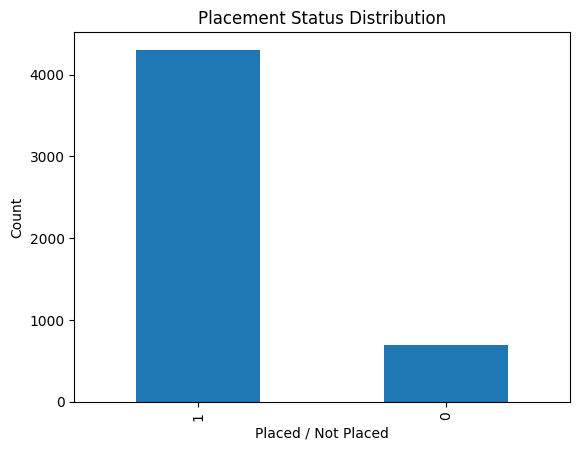

In [35]:
data['placement_status'].value_counts().plot(kind='bar')
plt.title("Placement Status Distribution")
plt.xlabel("Placed / Not Placed")
plt.ylabel("Count")
plt.show()

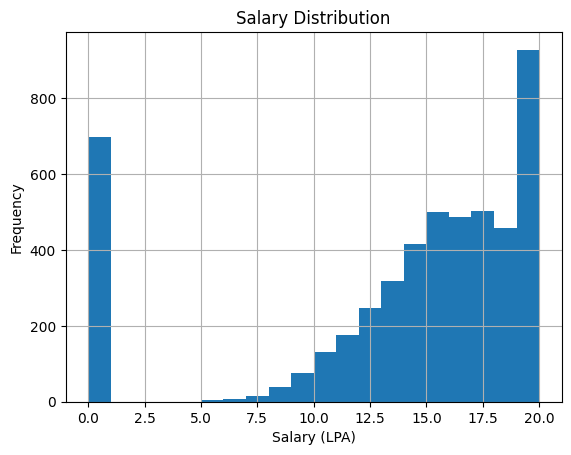

In [36]:
data['salary_lpa'].hist(bins=20)
plt.title("Salary Distribution")
plt.xlabel("Salary (LPA)")
plt.ylabel("Frequency")
plt.show()

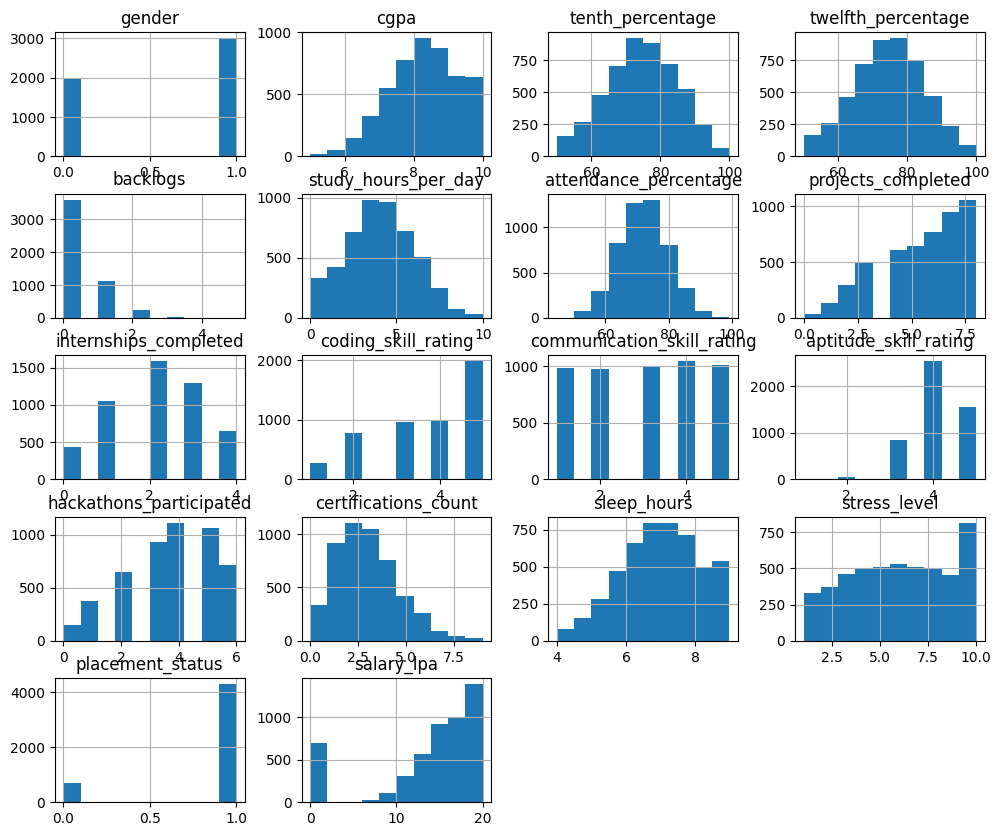

In [37]:
data.hist(figsize=(12,10))
plt.show()

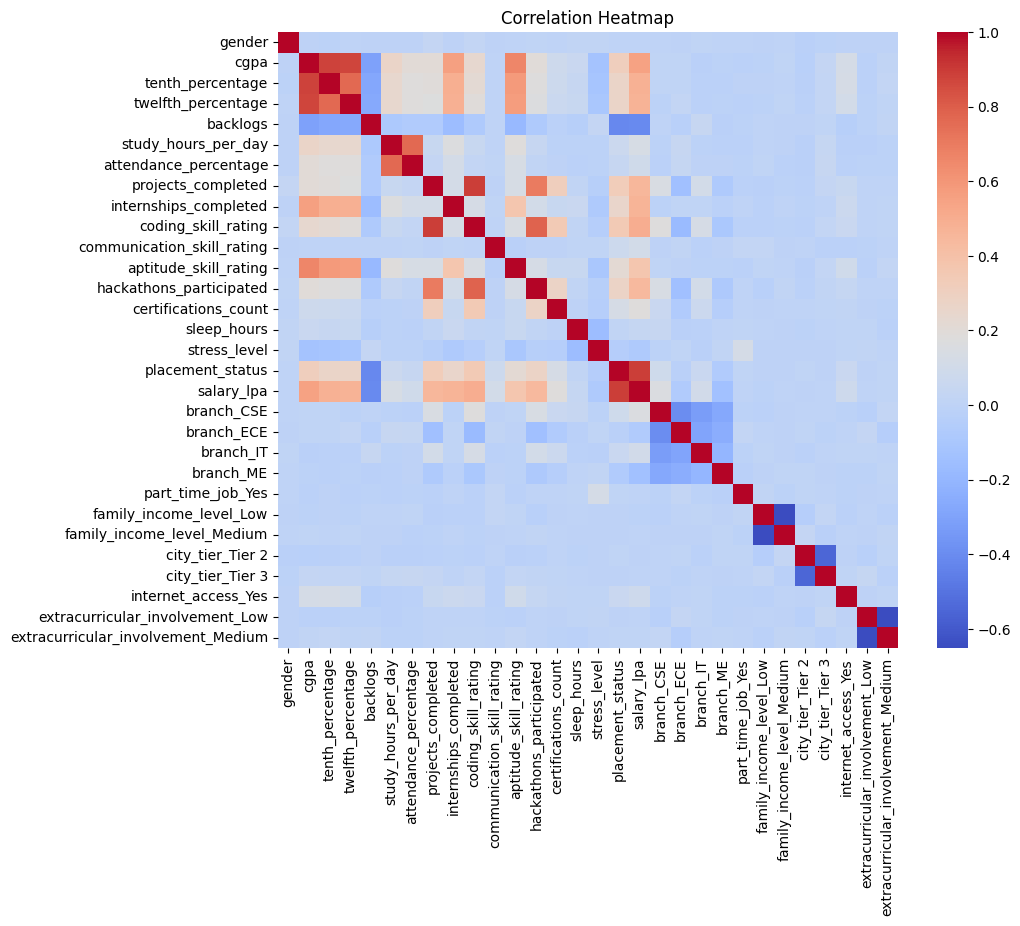

In [39]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

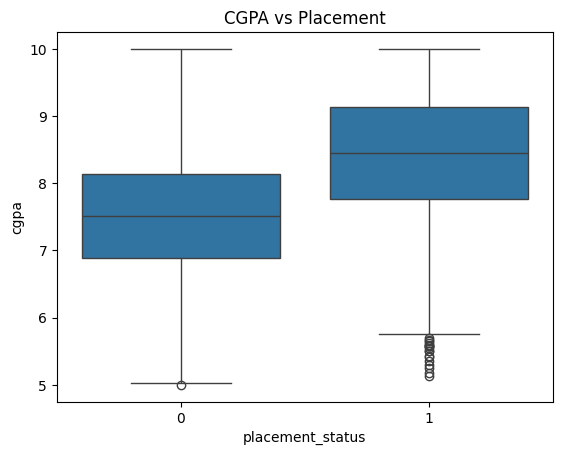

In [41]:
sns.boxplot(x='placement_status', y='cgpa', data=data)
plt.title("CGPA vs Placement")
plt.show()

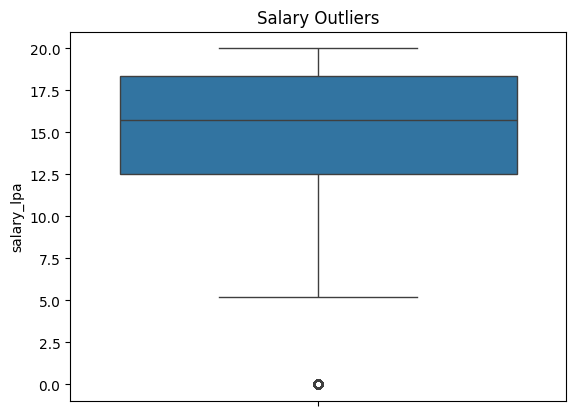

In [42]:
sns.boxplot(data['salary_lpa'])
plt.title("Salary Outliers")
plt.show()

In [51]:
from sklearn.model_selection import train_test_split

X = data.drop(["placement_status", "salary_lpa"], axis=1)
y = data["placement_status"]

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [66]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.3 MB/s eta 0:00:45
   ---------------------------------------- 0.5/101.7 MB 2.3 MB/s eta 0:00:45
   ---------------------------------------- 0.5/101.7 MB 2.3 MB/s eta 0:00:45
   ---------------------------------------- 0.8/101.7 MB 722.3 kB/s eta 0:02:20
    --------------------------------------- 1.3/101.7 MB 1.1 MB/s eta 0:01:33
    --------------------------------------- 1.8/101.7 MB 1.3 MB/s eta 0:01:18
   - -------------------------------------- 2.6/101.7 MB 1.6 MB/s eta 0:01:03
   - -------------------------------------- 3.4/101.7 MB 1.9 MB/s eta 0:00:52
   - -------------------------------------- 4.5/101.7 MB 2.3 MB/s eta 0:00:43
   --


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [71]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.894
Confusion Matrix:
 [[ 67  71]
 [ 35 827]]
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.49      0.56       138
           1       0.92      0.96      0.94       862

    accuracy                           0.89      1000
   macro avg       0.79      0.72      0.75      1000
weighted avg       0.88      0.89      0.89      1000



In [73]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [79]:
import pickle

pickle.dump(X.columns, open("columns.pkl", "wb"))

In [80]:
import pickle

model = pickle.load(open("model.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

# Create empty input
input_data = pd.DataFrame(columns=columns)

# Fill values
input_data.loc[0] = 0  # initialize all with 0

input_data['cgpa'] = cgpa
input_data['internships'] = internships
input_data['projects'] = projects
input_data['certifications'] = certifications

# Predict
prediction = model.predict(input_data)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


ValueError: X has 31 features, but LogisticRegression is expecting 28 features as input.